# Visualizing Dark Matter Limits

The computationally intensive pipeline required to extract the cross-section upper limits—such as the Likelihood Profiling and the $\langle \sigma v \rangle$ root-finding for either annihilation or decay—must be executed separately using the standalone Python scripts found on the ``cross_section_limits`` folder. In this folder you can find the instructions to make a successful execution of the scripts.

The methodology, scripts, and mock datasets used to generate these results are directly derived from the official [CTA-Padova KSP dSph material repository](https://gitlab.cta-observatory.org/cta-consortium/aswg/sandbox/cta-padova/ksp_dsph_material/-/tree/main?ref_type=heads). This repository collects the core analytical framework utilized in the following CTA Consortium publication:

>  **Paper:** Abe, K., et al. (2025). Prospects for dark matter observations in dwarf spheroidal galaxies with the Cherenkov Telescope Array Observatory. Monthly Notices of the Royal Astronomical Society, 544(3), 2946–2986. **DOI:** [10.1093/mnras/staf1798](https://doi.org/10.1093/mnras/staf1798)

In this notebook, we will take the output files generated by the external script and construct the final plots to compare our projected limits against the canonical thermal relic abundance.

### Visualizing the Sensitivity: The "Brazil Plot"


In astroparticle physics, expected sensitivities and upper limits are traditionally displayed using what are affectionately known as **"Brazil Plots"** (due to their characteristic green and yellow color scheme). 

This plot displays the upper limit on the Dark Matter annihilation cross-section ($\langle \sigma v \rangle$) as a function of the Dark Matter mass ($m_{DM}$). In this cell, we will plot:
* **The Median Limit (Black lines):** The median expected upper limit from our observations.
* **Uncertainty Bands with $\sigma_J$ (Green/Yellow):** The 68% ($1\sigma$) and 95% ($2\sigma$) containment bands incorporating the astrophysical uncertainty of the J-Factor.
* **Uncertainty Bands without $\sigma_J$ (Blues):** The idealized 68% and 95% bands assuming we know the J-Factor perfectly.
* **Thermal Relic Line (Purple):** The canonical cross-section required to produce the observed dark matter abundance in the early universe (Steigman 2012). 

*How to read this plot:* If our sensitivity line dips **below** the purple thermal relic line, it means our observation strategy is powerful enough to rule out standard WIMP Dark Matter at that specific mass!

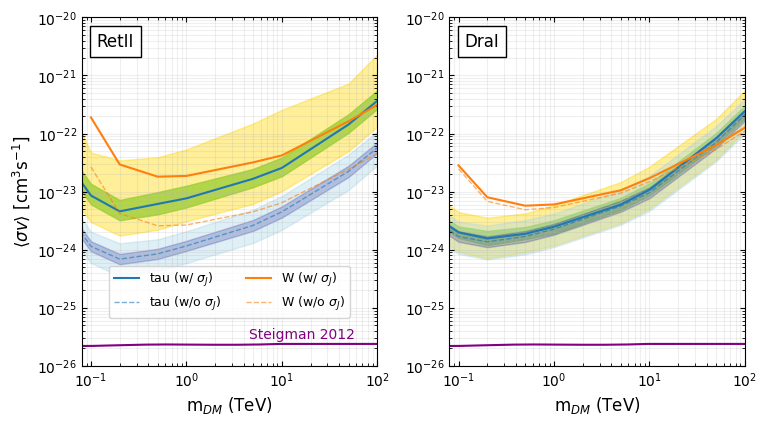

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText
import pandas as pd

# ==========================================
# 1. Analysis Configuration
# ==========================================
dSphNames = ['RetII', 'DraI'] 
profile = 'Einasto' 
channels = ['tau', 'W']

# Added color dictionary to distinguish channels
cmap = plt.get_cmap('tab10') 
line_colors = {channel: cmap(i) for i, channel in enumerate(channels)}

# Set a reference channel to plot the bands. 
# Set to 'None' to plot uncertainty bands for ALL channels.
reference_channel = 'tau' 

# ==========================================
# 2. Data Loading
# ==========================================
# Thermal relic abundance reference
relic = pd.read_csv('/Users/alexcervino/Desktop/DARKMATTER/ksp_dsph_material/plots/plots_limits/Relic_WIMP_Abundance.tsv', sep='\s+')

# Limits WITH J-factor uncertainty (wsj)
path_wsj = '/Users/alexcervino/Desktop/DARKMATTER/ksp_dsph_material/limits_wsj/annihilation/single/'
df_list_wsj = [pd.read_csv(f"{path_wsj}{name}_{profile}_annihilation_t100_wsj_quantiles.csv") for name in dSphNames]
df_wsj = pd.concat(df_list_wsj, ignore_index=True).drop_duplicates()
df_wsj['mass'] = df_wsj['mass'] / 1000  # Scale mass from GeV to TeV
df_wsj['name'] = df_wsj['src1']

# Limits WITHOUT J-factor uncertainty (wosj)
path_wosj = '/Users/alexcervino/Desktop/DARKMATTER/ksp_dsph_material/limits_wosj/annihilation/single/'
df_list = [pd.read_csv(f"{path_wosj}{name}_{profile}_annihilation_t100h_wosj_quantiles.csv") for name in dSphNames]
df = pd.concat(df_list, ignore_index=True).drop_duplicates()
df['mass'] = df['mass'] / 1000 # Scale mass from GeV to TeV

# ==========================================
# 3. Visualization (Brazil Plots)
# ==========================================
fig = plt.figure(figsize=(15, 8))

for count, name in enumerate(dSphNames, start=1):
    ax = plt.subplot(2, 4, count)
    
    for channel in channels:
        
        # Get specific color for the current channel (defaults to gray if not in dict)
        c_line = line_colors.get(channel, 'gray')

        # --- DATA WITH UNCERTAINTY (wsj) ---
        # Plot bands if reference_channel is None OR if the current channel matches the reference
        if reference_channel is None or channel == reference_channel:
            # 95% Band (2 sigma) - Gold
            mask_dw = (df_wsj['quantile'] == 0.05) & (df_wsj['name']==name) & (df_wsj['ch']==channel) & (df_wsj['profile']==profile)
            mask_up = (df_wsj['quantile'] == 0.95) & (df_wsj['name']==name) & (df_wsj['ch']==channel) & (df_wsj['profile']==profile)
            plt.fill_between(df_wsj[mask_dw]['mass'], df_wsj[mask_up]['sigma_v'], df_wsj[mask_dw]['sigma_v'], color='gold', alpha=0.4)

            # 68% Band (1 sigma) - Yellow-green
            mask_dw_1s = (df_wsj['quantile'] == 0.32) & (df_wsj['name']==name) & (df_wsj['ch']==channel) & (df_wsj['profile']==profile)
            mask_up_1s = (df_wsj['quantile'] == 0.68) & (df_wsj['name']==name) & (df_wsj['ch']==channel) & (df_wsj['profile']==profile)
            plt.fill_between(df_wsj[mask_dw_1s]['mass'], df_wsj[mask_up_1s]['sigma_v'], df_wsj[mask_dw_1s]['sigma_v'], color='yellowgreen', alpha=0.75)
        
        # Median (Plotted for ALL channels)
        mask_med = (df_wsj['quantile'] == 0.5) & (df_wsj['name']==name) & (df_wsj['profile']==profile) & (df_wsj['ch']==channel)
        plt.loglog(df_wsj[mask_med]['mass'], df_wsj[mask_med]['sigma_v'], ls='-', linewidth=1.5, color=c_line, label=f"{channel} (w/ $\sigma_J$)") 

        # --- DATA WITHOUT UNCERTAINTY (wosj) ---
        # Plot bands if reference_channel is None OR if the current channel matches the reference
        if reference_channel is None or channel == reference_channel:
            # 95% Band - Light blue
            mask_dw_wo = (df['quantile'] == 0.05) & (df['name']==name) & (df['ch']==channel) & (df['profile']==profile)
            mask_up_wo = (df['quantile'] == 0.95) & (df['name']==name) & (df['ch']==channel) & (df['profile']==profile)
            plt.fill_between(df[mask_dw_wo]['mass'], df[mask_up_wo]['sigma_v'], df[mask_dw_wo]['sigma_v'], color='lightblue', alpha=0.4)
            
            # 68% Band - Dark blue
            mask_dw_1s_wo = (df['quantile'] == 0.32) & (df['name']==name) & (df['ch']==channel) & (df['profile']==profile)
            mask_up_1s_wo = (df['quantile'] == 0.68) & (df['name']==name) & (df['ch']==channel) & (df['profile']==profile)
            plt.fill_between(df[mask_dw_1s_wo]['mass'], df[mask_up_1s_wo]['sigma_v'], df[mask_dw_1s_wo]['sigma_v'], color='darkblue', alpha=0.2)
        
        # Median (Plotted for ALL channels)
        mask_med_wo = (df['quantile'] == 0.5) & (df['name']==name) & (df['profile']==profile) & (df['ch']==channel)
        plt.loglog(df[mask_med_wo]['mass'], df[mask_med_wo]['sigma_v'], ls='--', linewidth=1, color=c_line, alpha=0.6, label=f"{channel} (w/o $\sigma_J$)") 

    # --- THERMAL RELIC & FORMATTING ---
    plt.plot(relic.mass*1e-3, relic.sigmav, color='purple')

    # Add source name box
    at = AnchoredText(name, loc='upper left', prop=dict(size=12), frameon=True)
    ax.add_artist(at)

    # Add legend and text only on the first subplot to avoid clutter
    if count == 1:
        plt.legend(loc='lower center', fontsize=9, ncols=2, bbox_to_anchor=(0.5, 0.12))
        plt.text(x=4.500, y=3e-26, s='Steigman 2012', color="purple")
        
    # Grid and limits
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.ylim(1e-26, 1e-20)
    plt.xlim(80*1e-3, 1e5*1e-3)
    
    # Axis labels
    if count in [1, 5]:
        plt.ylabel(r"$\langle \sigma v \rangle$ [cm$^3$s$^{-1}$]", fontsize=12)
    plt.xlabel("m$_{DM}$ (TeV)", fontsize=12)
    
    plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()